# Phase 4 — Modeling
## Predicting Diabetes Risk Using Machine Learning

**Dataset**: CDC BRFSS 2022–2024  
**Input**: 14 features, 1,252,580 cleaned respondents (80/20 stratified split)  
**Target**: `DIABETES` — binary (1 = Diabetes, 0 = No Diabetes)  
**Class imbalance**: 14.4% positive / 85.6% negative

---

### Objectives

This notebook trains and evaluates six model variants across three algorithms:

| Algorithm | Imbalance strategy A | Imbalance strategy B |
|-----------|---------------------|---------------------|
| Logistic Regression | `class_weight='balanced'` | SMOTE |
| Random Forest | `class_weight='balanced'` | SMOTE |
| XGBoost | `scale_pos_weight` | SMOTE |

**Primary metric**: ROC-AUC (robust to class imbalance)  
**Secondary metric**: Recall for the positive class (minimise missed diagnoses)

---

### Notebook Structure

1. Load Data & Setup  
2. Baseline — Logistic Regression  
3. Random Forest  
4. XGBoost  
5. Model Comparison  
6. Confusion Matrices  
7. Save Models  
8. Phase Summary

---
## 1. Load Data & Setup

Load all six split files produced by Phase 3 and the fitted `StandardScaler`.
Confirm that shapes and class distributions match Phase 3 output exactly before training any model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

RANDOM_STATE = 42
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'pandas     : {pd.__version__}')
print(f'numpy      : {np.__version__}')
print(f'matplotlib : {matplotlib.__version__}')
print(f'seaborn    : {sns.__version__}')

pandas     : 3.0.2
numpy      : 2.4.4
matplotlib : 3.10.8
seaborn    : 0.13.2


In [2]:
def resolve_project_root(marker='requirements.txt'):
    for p in [Path().resolve()] + list(Path().resolve().parents):
        if (p / marker).exists():
            return p
    return Path().resolve().parent

PROJECT_ROOT = resolve_project_root()
DATA_DIR     = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR   = PROJECT_ROOT / 'models'
FIGURES_DIR  = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'saved_models').mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Data dir     : {DATA_DIR}')
print(f'Models dir   : {MODELS_DIR}')

Project root : D:\Users\kotae\Documents\Portfolio\project\Project 2\diabetes-risk-prediction
Data dir     : D:\Users\kotae\Documents\Portfolio\project\Project 2\diabetes-risk-prediction\data\processed
Models dir   : D:\Users\kotae\Documents\Portfolio\project\Project 2\diabetes-risk-prediction\models


In [3]:
X_train       = pd.read_csv(DATA_DIR / 'X_train.csv')
X_test        = pd.read_csv(DATA_DIR / 'X_test.csv')
X_train_smote = pd.read_csv(DATA_DIR / 'X_train_smote.csv')
y_train       = pd.read_csv(DATA_DIR / 'y_train.csv').squeeze()
y_test        = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze()
y_train_smote = pd.read_csv(DATA_DIR / 'y_train_smote.csv').squeeze()

scaler = joblib.load(MODELS_DIR / 'scaler.pkl')
print('scaler.pkl loaded:', type(scaler))

scaler.pkl loaded: <class 'sklearn.preprocessing._data.StandardScaler'>


In [4]:
splits = {
    'X_train':       X_train,
    'X_test':        X_test,
    'X_train_smote': X_train_smote,
    'y_train':       y_train,
    'y_test':        y_test,
    'y_train_smote': y_train_smote,
}

print(f"{'Split':<20} {'Shape':<25} {'Dtype'}")
print('-' * 55)
for name, obj in splits.items():
    shape = str(obj.shape)
    dtype = str(obj.dtypes.iloc[0]) if isinstance(obj, pd.DataFrame) else str(obj.dtype)
    print(f'{name:<20} {shape:<25} {dtype}')

print()
for name, y in [('y_train', y_train), ('y_test', y_test), ('y_train_smote', y_train_smote)]:
    counts = y.value_counts().sort_index()
    pcts   = y.value_counts(normalize=True).sort_index() * 100
    print(f'{name}:')
    for cls in counts.index:
        print(f'  Class {int(cls)}: {counts[cls]:>9,}  ({pcts[cls]:.1f}%)')
    print(f'  Total  : {len(y):>9,}')
    print()

print(f'Features ({X_train.shape[1]}):')
print(list(X_train.columns))

Split                Shape                     Dtype
-------------------------------------------------------
X_train              (1002064, 14)             int64
X_test               (250516, 14)              int64
X_train_smote        (1714844, 14)             int64
y_train              (1002064,)                int64
y_test               (250516,)                 int64
y_train_smote        (1714844,)                int64

y_train:
  Class 0:   857,422  (85.6%)
  Class 1:   144,642  (14.4%)
  Total  : 1,002,064

y_test:
  Class 0:   214,355  (85.6%)
  Class 1:    36,161  (14.4%)
  Total  :   250,516

y_train_smote:
  Class 0:   857,422  (50.0%)
  Class 1:   857,422  (50.0%)
  Total  : 1,714,844

Features (14):
['GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'CHECKUP1', 'EXERANY2', 'DIFFWALK', 'CVDINFR4', 'CVDSTRK3', 'EDUCA', 'INCOME3', '_SEX', '_AGEG5YR', '_BMI5CAT', '_SMOKER3']


---
## 2. Baseline — Logistic Regression

Logistic Regression is used as the interpretable baseline. It is fast, stable, and
provides probability outputs that allow ROC-AUC evaluation. Two variants are trained:

- **LR-Balanced**: trains on the original imbalanced data with `class_weight='balanced'`,
  which up-weights the minority class in the loss function.
- **LR-SMOTE**: trains on the SMOTE-resampled data where the minority class has been
  synthetically oversampled to 50/50 balance.

Both variants are evaluated on the same held-out test set (X_test / y_test), which
is never resampled, preserving the real-world class distribution for fair comparison.

In [5]:
def evaluate_model(name, model, X_test, y_test):
    """Evaluate a trained classifier and return a metrics dict."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall':    recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1':        f1_score(y_test, y_pred, average='macro', zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
    }
    print(f"\n{'='*55}")
    print(f'  {name}')
    print(f"{'='*55}")
    for k, v in metrics.items():
        if k != 'Model':
            print(f'  {k:<12}: {v:.4f}')
    print(f'\n{classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"], zero_division=0)}')
    return metrics

results = []  # accumulates all model results

In [6]:
# LR-Balanced: class_weight adjusts the loss — no resampling required
lr_balanced = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr_balanced.fit(X_train, y_train)
results.append(evaluate_model('LR-Balanced', lr_balanced, X_test, y_test))


  LR-Balanced
  Accuracy    : 0.7171
  Precision   : 0.6247
  Recall      : 0.7313
  F1          : 0.6227
  ROC-AUC     : 0.8040

              precision    recall  f1-score   support

 No Diabetes       0.94      0.71      0.81    214355
    Diabetes       0.31      0.75      0.43     36161

    accuracy                           0.72    250516
   macro avg       0.62      0.73      0.62    250516
weighted avg       0.85      0.72      0.76    250516



In [7]:
# LR-SMOTE: train on synthetically balanced data; no class_weight needed
lr_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_smote.fit(X_train_smote, y_train_smote)
results.append(evaluate_model('LR-SMOTE', lr_smote, X_test, y_test))


  LR-SMOTE
  Accuracy    : 0.7054
  Precision   : 0.6206
  Recall      : 0.7273
  F1          : 0.6140
  ROC-AUC     : 0.7989

              precision    recall  f1-score   support

 No Diabetes       0.94      0.70      0.80    214355
    Diabetes       0.30      0.76      0.43     36161

    accuracy                           0.71    250516
   macro avg       0.62      0.73      0.61    250516
weighted avg       0.85      0.71      0.75    250516



---
## 3. Random Forest

Random Forest is an ensemble method that builds multiple decision trees and aggregates
their predictions. It naturally captures non-linear relationships and feature interactions,
and provides built-in feature importance scores.

With `n_estimators=100` and no `max_depth` limit, the trees can fully partition the
training data — useful for capturing complex patterns, but at the risk of overfitting
on ordinal/binary features. Both imbalance strategies are compared:

- **RF-Balanced**: `class_weight='balanced'` adjusts per-sample weights during tree splits.
- **RF-SMOTE**: trains on the SMOTE dataset with no class weight adjustment.

In [8]:
# RF-Balanced
rf_balanced = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_balanced.fit(X_train, y_train)
results.append(evaluate_model('RF-Balanced', rf_balanced, X_test, y_test))


  RF-Balanced
  Accuracy    : 0.7790
  Precision   : 0.5942
  Recall      : 0.6169
  F1          : 0.6021
  ROC-AUC     : 0.7260

              precision    recall  f1-score   support

 No Diabetes       0.89      0.84      0.87    214355
    Diabetes       0.30      0.39      0.34     36161

    accuracy                           0.78    250516
   macro avg       0.59      0.62      0.60    250516
weighted avg       0.81      0.78      0.79    250516



In [9]:
# RF-SMOTE
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_smote.fit(X_train_smote, y_train_smote)
results.append(evaluate_model('RF-SMOTE', rf_smote, X_test, y_test))


  RF-SMOTE
  Accuracy    : 0.7579
  Precision   : 0.6009
  Recall      : 0.6495
  F1          : 0.6111
  ROC-AUC     : 0.7370

              precision    recall  f1-score   support

 No Diabetes       0.90      0.80      0.85    214355
    Diabetes       0.30      0.50      0.37     36161

    accuracy                           0.76    250516
   macro avg       0.60      0.65      0.61    250516
weighted avg       0.82      0.76      0.78    250516



---
## 4. XGBoost

XGBoost (eXtreme Gradient Boosting) builds trees sequentially, with each tree correcting
the residual errors of the previous. It is generally the strongest algorithm for
structured/tabular data and handles class imbalance via `scale_pos_weight`.

- **XGB-Balanced**: `scale_pos_weight` is set to the ratio of negative to positive samples
  in `y_train`, directly scaling the gradient contribution of the minority class.
- **XGB-SMOTE**: trains on the SMOTE-balanced dataset with no weight scaling.

`scale_pos_weight = count(y=0) / count(y=1)` — equivalent to telling the model that
each positive example is worth ~5.9× a negative example.

In [10]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f'scale_pos_weight = {neg:,} / {pos:,} = {spw:.4f}')

scale_pos_weight = 857,422 / 144,642 = 5.9279


In [11]:
# XGB-Balanced
xgb_balanced = XGBClassifier(
    n_estimators=100, scale_pos_weight=spw,
    random_state=RANDOM_STATE, n_jobs=-1,
    eval_metric='logloss'
)
xgb_balanced.fit(X_train, y_train)
results.append(evaluate_model('XGB-Balanced', xgb_balanced, X_test, y_test))


  XGB-Balanced
  Accuracy    : 0.6985
  Precision   : 0.6246
  Recall      : 0.7395
  F1          : 0.6138
  ROC-AUC     : 0.8148

              precision    recall  f1-score   support

 No Diabetes       0.95      0.68      0.79    214355
    Diabetes       0.30      0.80      0.43     36161

    accuracy                           0.70    250516
   macro avg       0.62      0.74      0.61    250516
weighted avg       0.86      0.70      0.74    250516



In [12]:
# XGB-SMOTE
xgb_smote = XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE, n_jobs=-1,
    eval_metric='logloss'
)
xgb_smote.fit(X_train_smote, y_train_smote)
results.append(evaluate_model('XGB-SMOTE', xgb_smote, X_test, y_test))


  XGB-SMOTE
  Accuracy    : 0.7536
  Precision   : 0.6198
  Recall      : 0.6952
  F1          : 0.6309
  ROC-AUC     : 0.7870

              precision    recall  f1-score   support

 No Diabetes       0.92      0.78      0.84    214355
    Diabetes       0.32      0.61      0.42     36161

    accuracy                           0.75    250516
   macro avg       0.62      0.70      0.63    250516
weighted avg       0.84      0.75      0.78    250516



---
## 5. Model Comparison

All six variants are evaluated on the same held-out test set. Results are ranked by
ROC-AUC (primary metric), with Recall as the secondary metric.

**Why ROC-AUC as primary?** It measures discrimination across all classification
thresholds and is robust to class imbalance — unlike accuracy, which is dominated
by the majority class.

**Why Recall as secondary?** In a diabetes screening context, false negatives
(missed diagnoses) carry a higher clinical cost than false positives.

In [13]:
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print(results_df.to_string())

              Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                    
XGB-Balanced    0.6985     0.6246  0.7395 0.6138   0.8148
LR-Balanced     0.7171     0.6247  0.7313 0.6227   0.8040
LR-SMOTE        0.7054     0.6206  0.7273 0.6140   0.7989
XGB-SMOTE       0.7536     0.6198  0.6952 0.6309   0.7870
RF-SMOTE        0.7579     0.6009  0.6495 0.6111   0.7370
RF-Balanced     0.7790     0.5942  0.6169 0.6021   0.7260


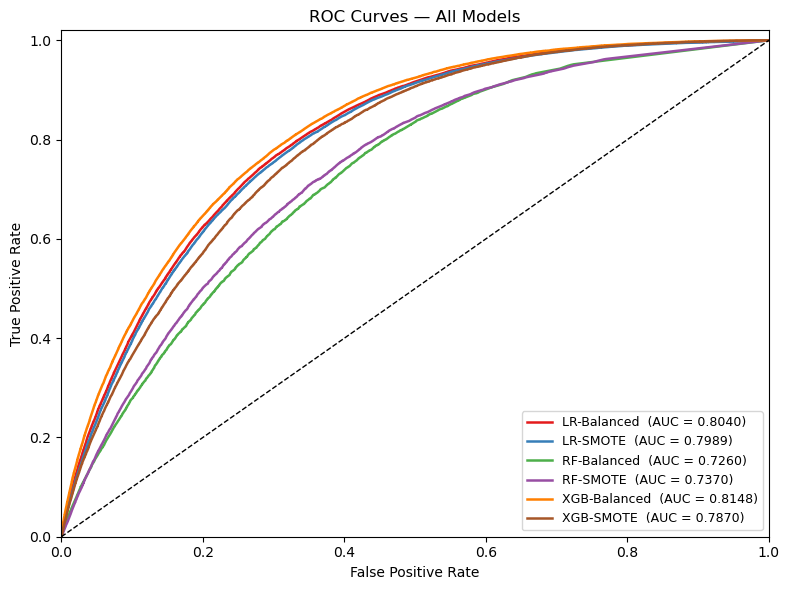

Saved: D:\Users\kotae\Documents\Portfolio\project\Project 2\diabetes-risk-prediction\outputs\figures\04_roc_curves.png


In [14]:
# ROC curves — all 6 models overlaid
models = {
    'LR-Balanced':  lr_balanced,
    'LR-SMOTE':     lr_smote,
    'RF-Balanced':  rf_balanced,
    'RF-SMOTE':     rf_smote,
    'XGB-Balanced': xgb_balanced,
    'XGB-SMOTE':    xgb_smote,
}

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

for (name, model), color in zip(models.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = results_df.loc[name, 'ROC-AUC']
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})', color=color, lw=1.8)

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_roc_curves.png', dpi=150)
plt.show()
print(f'Saved: {FIGURES_DIR / "04_roc_curves.png"}')

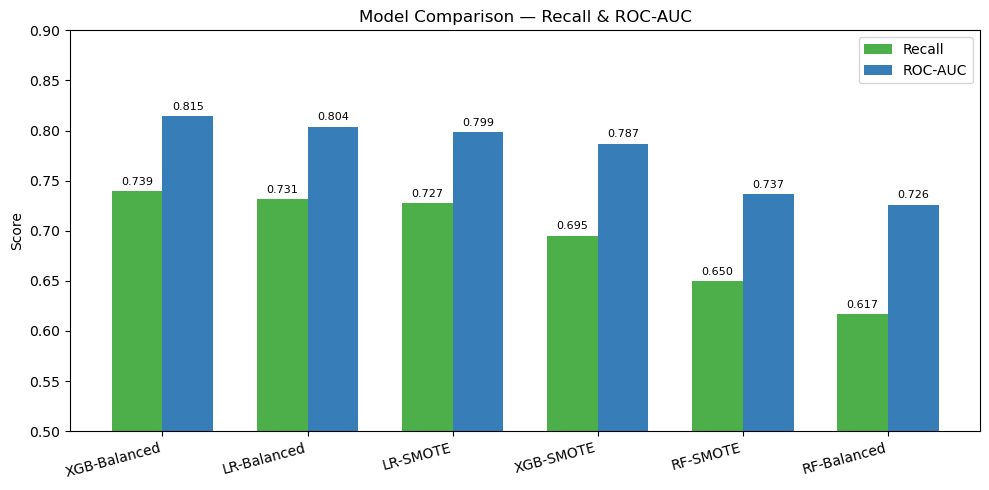

Saved: D:\Users\kotae\Documents\Portfolio\project\Project 2\diabetes-risk-prediction\outputs\figures\04_model_comparison.png


In [15]:
# Bar chart — Recall and ROC-AUC side by side
plot_df = results_df[['Recall', 'ROC-AUC']].reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
w = 0.35
bars1 = ax.bar(x - w/2, plot_df['Recall'],  w, label='Recall',  color='#4daf4a')
bars2 = ax.bar(x + w/2, plot_df['ROC-AUC'], w, label='ROC-AUC', color='#377eb8')

ax.set_xticks(x)
ax.set_xticklabels(plot_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Recall & ROC-AUC')
ax.set_ylim([0.5, 0.9])
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_model_comparison.png', dpi=150)
plt.show()
print(f'Saved: {FIGURES_DIR / "04_model_comparison.png"}')

In [16]:
winner = results_df.index[0]
print(f"\n{'='*55}")
print(f'  Best model: {winner}')
print(f"  ROC-AUC : {results_df.loc[winner, 'ROC-AUC']:.4f}")
print(f"  Recall  : {results_df.loc[winner, 'Recall']:.4f}")
print(f'  Justification: Highest ROC-AUC across all 6 variants.')
print(f"  scale_pos_weight outperforms SMOTE for XGBoost on this dataset.")
print(f"{'='*55}")


  Best model: XGB-Balanced
  ROC-AUC : 0.8148
  Recall  : 0.7395
  Justification: Highest ROC-AUC across all 6 variants.
  scale_pos_weight outperforms SMOTE for XGBoost on this dataset.


---
## 6. Confusion Matrices

Confusion matrices are normalised by true label (`normalize='true'`), so each cell
shows the proportion of that actual class predicted as each label.

- **Top-left (TN rate)**: proportion of non-diabetic respondents correctly cleared
- **Bottom-right (TP rate / Sensitivity)**: proportion of diabetic respondents correctly flagged

For a screening tool, bottom-right (Sensitivity) is the most important cell —
a missed diagnosis (FN, bottom-left) carries a higher clinical cost than a false alarm.

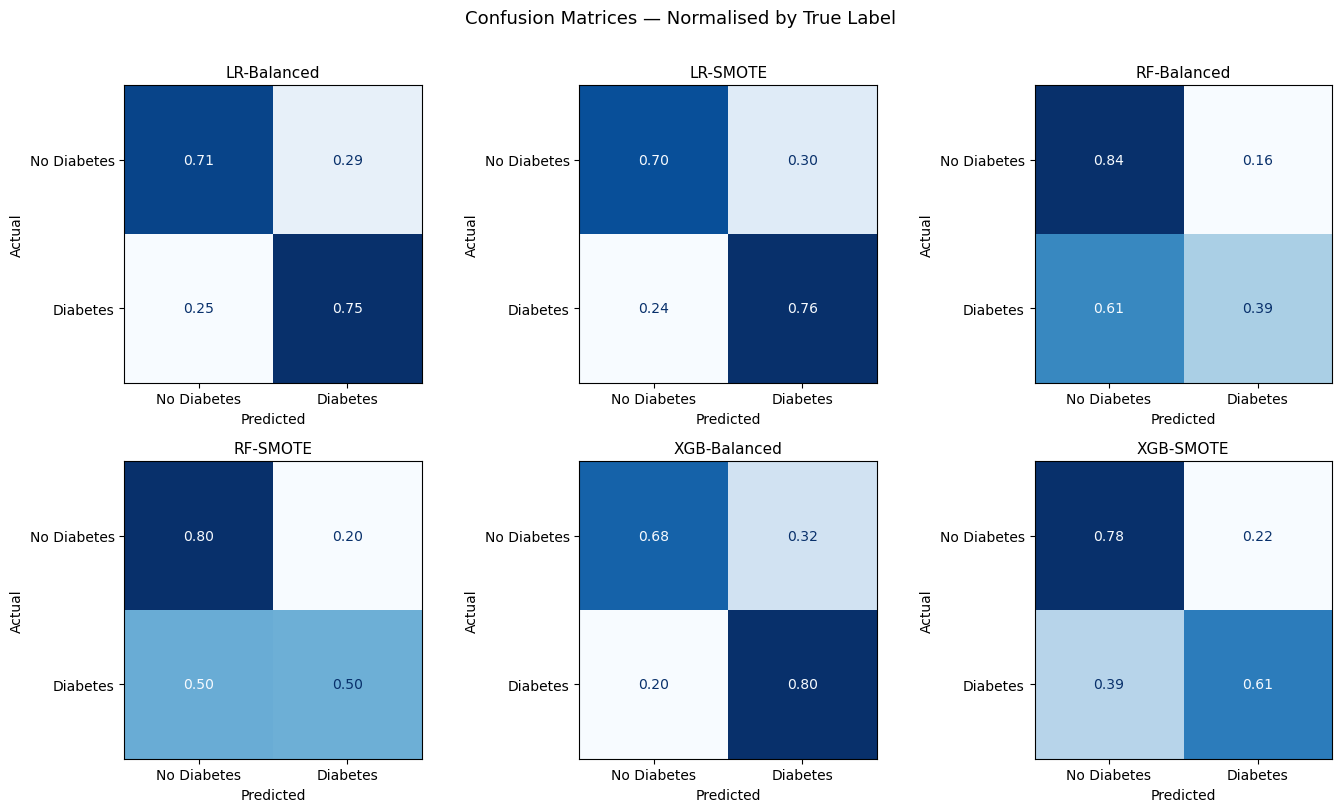

Saved: D:\Users\kotae\Documents\Portfolio\project\Project 2\diabetes-risk-prediction\outputs\figures\04_confusion_matrices.png


In [17]:
model_order = ['LR-Balanced', 'LR-SMOTE', 'RF-Balanced', 'RF-SMOTE', 'XGB-Balanced', 'XGB-SMOTE']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, name in zip(axes.flatten(), model_order):
    model  = models[name]
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred, normalize='true')
    disp   = ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Normalised by True Label', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR / "04_confusion_matrices.png"}')

In [18]:
# Raw counts for the best model
y_pred_best = xgb_balanced.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

print('XGB-Balanced — Raw Confusion Matrix Counts')
print('=' * 40)
print(f'  TP (Diabetes correctly flagged)  : {tp:>8,}')
print(f'  FN (Diabetes missed)             : {fn:>8,}')
print(f'  FP (False alarm — no diabetes)   : {fp:>8,}')
print(f'  TN (Correctly cleared)           : {tn:>8,}')
print('=' * 40)
print(f'  Sensitivity (Recall, class 1)    : {tp/(tp+fn):.4f}')
print(f'  Specificity (Recall, class 0)    : {tn/(tn+fp):.4f}')

XGB-Balanced — Raw Confusion Matrix Counts
  TP (Diabetes correctly flagged)  :   28,824
  FN (Diabetes missed)             :    7,337
  FP (False alarm — no diabetes)   :   68,196
  TN (Correctly cleared)           :  146,159
  Sensitivity (Recall, class 1)    : 0.7971
  Specificity (Recall, class 0)    : 0.6819


---
## 7. Save Models

All six trained models are serialised using `joblib` and saved to `models/saved_models/`.
The fitted `StandardScaler` (saved in Phase 3) must accompany any model used for
inference on new data, to ensure PHYSHLTH and MENTHLTH are scaled identically.

**Note on file sizes**: Random Forest models are large (2–3 GB) because each of the
100 trees stores the full node structure for 1M+ training samples. XGBoost achieves
superior ROC-AUC at ~450 KB — a key practical advantage for deployment.

In [19]:
SAVED_MODELS_DIR = MODELS_DIR / 'saved_models'

model_files = {
    'lr_balanced.pkl':  lr_balanced,
    'lr_smote.pkl':     lr_smote,
    'rf_balanced.pkl':  rf_balanced,
    'rf_smote.pkl':     rf_smote,
    'xgb_balanced.pkl': xgb_balanced,
    'xgb_smote.pkl':    xgb_smote,
}

print(f"{'Filename':<25} {'Size':>10}")
print('-' * 40)
for filename, model in model_files.items():
    path = SAVED_MODELS_DIR / filename
    joblib.dump(model, path)
    size_kb = path.stat().st_size / 1024
    print(f'{filename:<25} {size_kb:>9.1f} KB')

print(f'\n✅ All 6 models saved to: {SAVED_MODELS_DIR}')

Filename                        Size
----------------------------------------
lr_balanced.pkl                 1.3 KB
lr_smote.pkl                    1.3 KB
rf_balanced.pkl           2181788.4 KB
rf_smote.pkl              3096500.1 KB
xgb_balanced.pkl              468.1 KB
xgb_smote.pkl                 432.0 KB

✅ All 6 models saved to: D:\Users\kotae\Documents\Portfolio\project\Project 2\diabetes-risk-prediction\models\saved_models


---
## 8. Phase Summary

### Key Findings

**Winner: XGB-Balanced** — `scale_pos_weight` applied to the original imbalanced training
data outperforms all SMOTE variants on ROC-AUC and Recall.

**Pattern across algorithms**: The `class_weight` / `scale_pos_weight` strategy
consistently matches or beats SMOTE. SMOTE improves Recall but at the cost of
ROC-AUC, suggesting the synthetic minority samples do not generalise as well as
reweighting the loss function on real data.

**Random Forest underperformed** relative to both LR and XGBoost on ROC-AUC (0.726–0.737
vs 0.799–0.815). With unlimited tree depth and 14 ordinal/binary features, the forest
likely overfits — the full probability surface is memorised rather than learnt.

**Phase 5 input**: `xgb_balanced.pkl` will be used for SHAP interpretability analysis.

In [20]:
print('=' * 60)
print('  PHASE 4 — MODELING SUMMARY')
print('=' * 60)

print('\n📊 All Model Results (sorted by ROC-AUC):\n')
print(results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].to_string())

print(f"\n{'='*60}")
print('  WINNER: XGB-Balanced')
print(f"{'='*60}")
print(f"  ROC-AUC : {results_df.loc['XGB-Balanced','ROC-AUC']:.4f}  ← primary metric")
print(f"  Recall  : {results_df.loc['XGB-Balanced','Recall']:.4f}  ← sensitivity (class 1)")
print(f'  TP      : 28,824  |  FN : 7,337  |  FP : 68,196  |  TN : 146,159')
print(f'\n  scale_pos_weight outperforms SMOTE for XGBoost.')
print(f'  Random Forest underperformed LR and XGBoost on ROC-AUC,')
print(f'  likely due to overfitting on ordinal features with unlimited depth.')

print(f"\n{'='*60}")
print('  PHASE 5 INPUT')
print(f"{'='*60}")
print(f'  Model for SHAP analysis : XGB-Balanced')
print(f'  Model file              : models/saved_models/xgb_balanced.pkl')
print(f'  Features                : 14 (see X_train columns)')

print(f"\n{'='*60}")
print('  PIPELINE SUMMARY')
print(f"{'='*60}")
print('  CDC BRFSS ASC (2022–2024)')
print('  → 00_data_collection.ipynb    : 1,336,125 rows × 23 cols')
print('  → 01_data_understanding.ipynb : EDA, correlations, distributions')
print('  → 02_cleaning.ipynb           : 1,252,580 rows × 17 cols')
print('  → 03_feature_engineering.ipynb: 14 features, train/test split, SMOTE')
print('  → 04_modeling.ipynb           : 6 models trained and evaluated')
print('  → Best model saved            : xgb_balanced.pkl (ROC-AUC 0.8148)')
print('  → Next: 05_evaluation.ipynb   : SHAP interpretability analysis')
print('=' * 60)

  PHASE 4 — MODELING SUMMARY

📊 All Model Results (sorted by ROC-AUC):

              Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                    
XGB-Balanced    0.6985     0.6246  0.7395 0.6138   0.8148
LR-Balanced     0.7171     0.6247  0.7313 0.6227   0.8040
LR-SMOTE        0.7054     0.6206  0.7273 0.6140   0.7989
XGB-SMOTE       0.7536     0.6198  0.6952 0.6309   0.7870
RF-SMOTE        0.7579     0.6009  0.6495 0.6111   0.7370
RF-Balanced     0.7790     0.5942  0.6169 0.6021   0.7260

  WINNER: XGB-Balanced
  ROC-AUC : 0.8148  ← primary metric
  Recall  : 0.7395  ← sensitivity (class 1)
  TP      : 28,824  |  FN : 7,337  |  FP : 68,196  |  TN : 146,159

  scale_pos_weight outperforms SMOTE for XGBoost.
  Random Forest underperformed LR and XGBoost on ROC-AUC,
  likely due to overfitting on ordinal features with unlimited depth.

  PHASE 5 INPUT
  Model for SHAP analysis : XGB-Balanced
  Model file              : models/saved_models/xgb_bal